# Homework: Monte Carlo integration

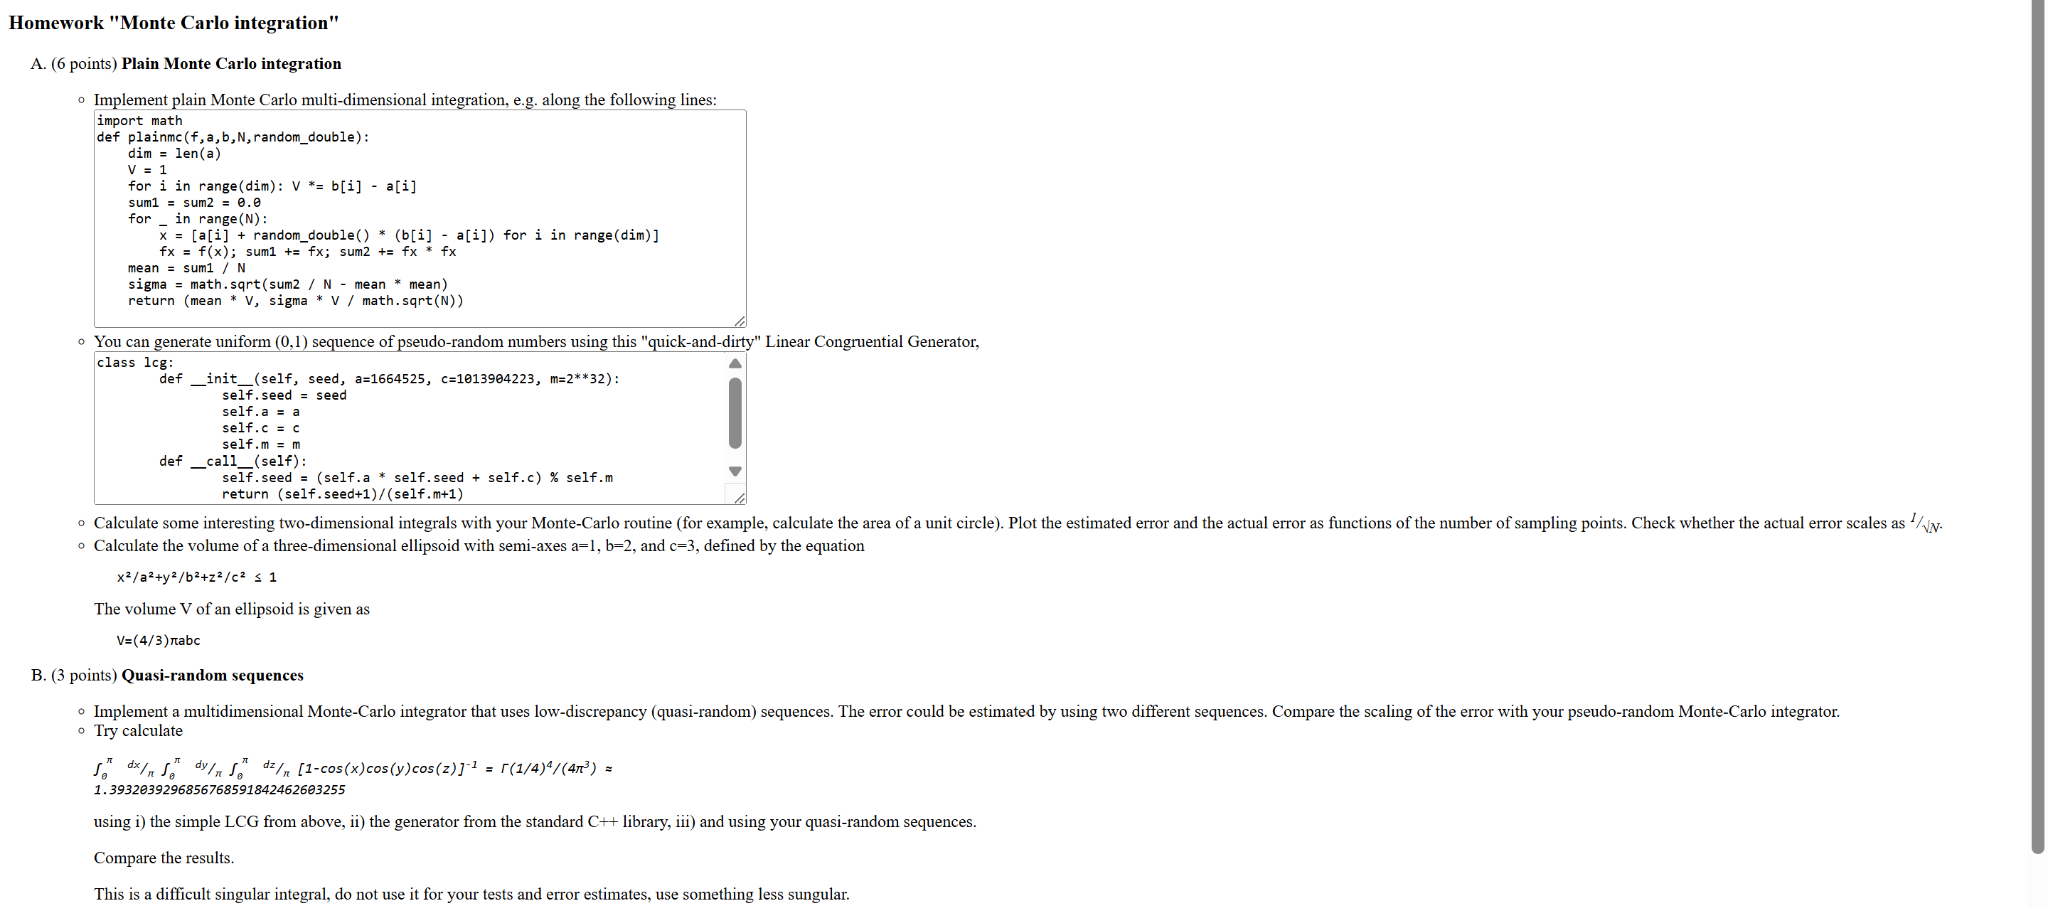

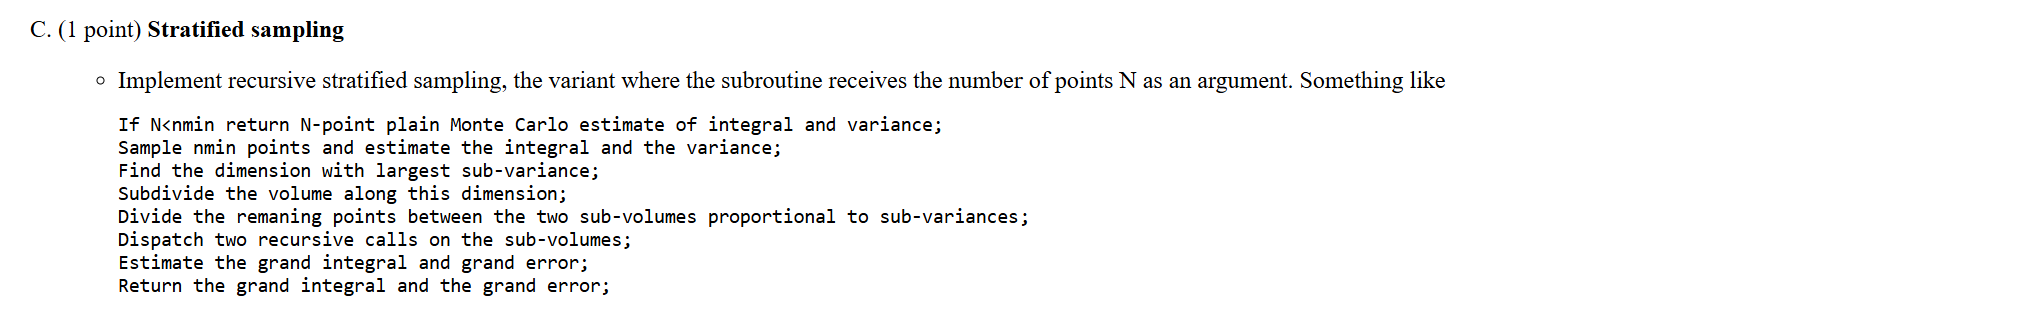

The structure is:

- Task A: plain Monte Carlo integration
- Task B: quasi-random sequences
- Task C: stratified sampling

# Task A: Plain Monte Carlo integration

In this task I implement a plain multidimensional Monte Carlo integrator.

For an integral over a rectangular volume,

$$
I = \int_a^b f(x)\,dx,
$$

random points are sampled uniformly in the integration region. The integral is estimated as

$$
I \approx V \langle f \rangle,
$$

where $V$ is the volume of the integration region.

The statistical uncertainty is estimated from the variance of the sampled function values,

$$
\sigma_I = V \sqrt{\frac{\langle f^2\rangle-\langle f\rangle^2}{N}}.
$$

The method is tested by calculating the area of the unit circle and the volume of a three-dimensional ellipsoid.

In [2]:
from pathlib import Path

Path("mc.hpp").write_text(r'''
#pragma once

#include <cmath>
#include <functional>
#include <random>
#include <vector>
#include <stdexcept>

namespace pp {

using vector = std::vector<double>;

struct mc_result {
    double value;
    double error;
};

class lcg {
private:
    unsigned long long seed;
    static constexpr unsigned long long a = 1664525;
    static constexpr unsigned long long c = 1013904223;
    static constexpr unsigned long long m = 4294967296ULL; // 2^32

public:
    explicit lcg(unsigned long long seed_) : seed(seed_) {}

    double operator()() {
        seed = (a*seed + c) % m;
        return static_cast<double>(seed) / static_cast<double>(m);
    }
};

template<class RNG>
mc_result plainmc(
    const std::function<double(const vector&)>& f,
    const vector& a,
    const vector& b,
    int N,
    RNG& rng
) {
    if (a.size() != b.size()) {
        throw std::runtime_error("plainmc: a and b must have same dimension");
    }

    if (N <= 1) {
        throw std::runtime_error("plainmc: N must be larger than 1");
    }

    int dim = static_cast<int>(a.size());

    double volume = 1.0;
    for (int i = 0; i < dim; ++i) {
        volume *= b[i] - a[i];
    }

    double sum = 0.0;
    double sum2 = 0.0;
    vector x(dim);

    for (int i = 0; i < N; ++i) {
        for (int k = 0; k < dim; ++k) {
            x[k] = a[k] + rng()*(b[k] - a[k]);
        }

        double fx = f(x);
        sum += fx;
        sum2 += fx*fx;
    }

    double mean = sum/N;
    double variance = sum2/N - mean*mean;

    if (variance < 0.0) {
        variance = 0.0;
    }

    double value = volume*mean;
    double error = volume*std::sqrt(variance/N);

    return mc_result{value, error};
}

} // namespace pp
''')

print("Wrote mc.hpp")

Wrote mc.hpp


In [3]:
Path("mc_A.cpp").write_text(r'''
#include "mc.hpp"

#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <random>
#include <vector>

int main() {
    std::cout << std::setprecision(12);

    const double pi = std::acos(-1.0);

    std::cout << "Task A: plain Monte Carlo integration\n";
    std::cout << "-------------------------------------\n\n";

    // --------------------------------------------------
    // Unit circle area
    // --------------------------------------------------

    pp::vector a_circle = {-1.0, -1.0};
    pp::vector b_circle = { 1.0,  1.0};

    auto circle_indicator = [](const pp::vector& x) {
        double r2 = x[0]*x[0] + x[1]*x[1];
        return r2 <= 1.0 ? 1.0 : 0.0;
    };

    double exact_circle_area = pi;

    std::ofstream circle_out("mc_A_circle.data");
    circle_out << "# N estimate estimated_error actual_error expected_1_over_sqrtN\n";

    std::vector<int> Ns = {
        100, 300, 1000, 3000, 10000, 30000, 100000, 300000, 1000000
    };

    std::cout << "Unit circle area test\n";
    std::cout << "exact area = pi = " << exact_circle_area << "\n\n";

    for (int N : Ns) {
        pp::lcg rng(12345);

        auto result = pp::plainmc(circle_indicator, a_circle, b_circle, N, rng);
        double actual_error = std::abs(result.value - exact_circle_area);
        double expected_scaling = 1.0/std::sqrt(static_cast<double>(N));

        circle_out << N << " "
                   << result.value << " "
                   << result.error << " "
                   << actual_error << " "
                   << expected_scaling << "\n";

        std::cout << "N = " << std::setw(8) << N
                  << "  estimate = " << std::setw(14) << result.value
                  << "  estimated error = " << std::setw(14) << result.error
                  << "  actual error = " << actual_error << "\n";
    }

    std::cout << "\nWrote mc_A_circle.data\n\n";

    // --------------------------------------------------
    // Ellipsoid volume
    // --------------------------------------------------

    double ax = 1.0;
    double by = 2.0;
    double cz = 3.0;

    pp::vector a_ellipsoid = {-ax, -by, -cz};
    pp::vector b_ellipsoid = { ax,  by,  cz};

    auto ellipsoid_indicator = [=](const pp::vector& x) {
        double q =
            x[0]*x[0]/(ax*ax)
            + x[1]*x[1]/(by*by)
            + x[2]*x[2]/(cz*cz);

        return q <= 1.0 ? 1.0 : 0.0;
    };

    double exact_ellipsoid_volume = 4.0*pi*ax*by*cz/3.0;

    std::cout << "Ellipsoid volume test\n";
    std::cout << "semi-axes: a = " << ax << ", b = " << by << ", c = " << cz << "\n";
    std::cout << "exact volume = 4*pi*a*b*c/3 = " << exact_ellipsoid_volume << "\n\n";

    pp::lcg rng_ellipsoid(6789);
    int N_ellipsoid = 1000000;

    auto ellipsoid_result =
        pp::plainmc(ellipsoid_indicator, a_ellipsoid, b_ellipsoid, N_ellipsoid, rng_ellipsoid);

    double ellipsoid_actual_error =
        std::abs(ellipsoid_result.value - exact_ellipsoid_volume);

    std::cout << "N = " << N_ellipsoid << "\n";
    std::cout << "estimated volume = " << ellipsoid_result.value << "\n";
    std::cout << "estimated error  = " << ellipsoid_result.error << "\n";
    std::cout << "actual error     = " << ellipsoid_actual_error << "\n";

    return 0;
}
''')

print("Wrote mc_A.cpp")

Wrote mc_A.cpp


In [4]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "mc_A.cpp",
    "-o",
    "mc_A"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./mc_A"], text=True, capture_output=True, timeout=30)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A: plain Monte Carlo integration
-------------------------------------

Unit circle area test
exact area = pi = 3.14159265359

N =      100  estimate =           3.12  estimated error = 0.165698521418  actual error = 0.0215926535898
N =      300  estimate =  3.17333333333  estimated error = 0.0935109421207  actual error = 0.0317406797435
N =     1000  estimate =          3.188  estimated error = 0.0508788364647  actual error = 0.0464073464102
N =     3000  estimate =  3.16933333333  estimated error = 0.0296235241858  actual error = 0.0277406797435
N =    10000  estimate =         3.1516  estimated error = 0.0163518116428  actual error = 0.0100073464102
N =    30000  estimate =  3.14613333333  estimated error = 0.00946287197811  actual error = 0.00454067974354
N =   100000  estimate =        3.13324  estimated error = 0.00521130223879  actual error = 0.00835265358979
N =   300000  estimate =        3.14052  estimated error = 0.00299956337356  actu

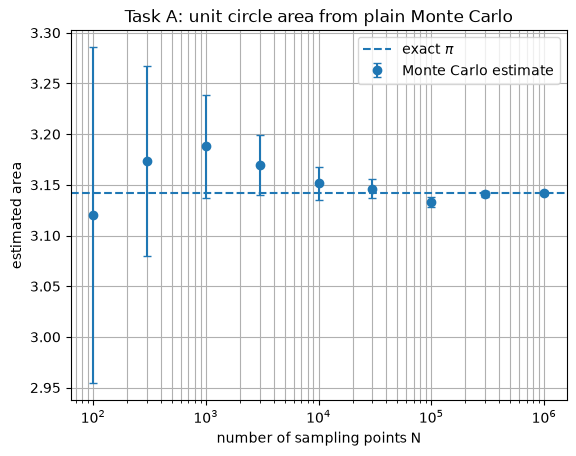

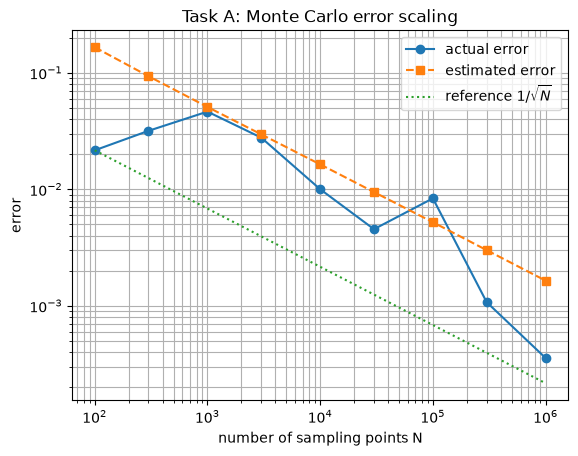

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("mc_A_circle.data")

N = data[:, 0]
estimate = data[:, 1]
estimated_error = data[:, 2]
actual_error = data[:, 3]
expected_scaling = data[:, 4]

pi = np.pi

plt.figure()
plt.errorbar(N, estimate, yerr=estimated_error, fmt="o", capsize=3, label="Monte Carlo estimate")
plt.axhline(pi, linestyle="--", label=r"exact $\pi$")
plt.xscale("log")
plt.xlabel("number of sampling points N")
plt.ylabel("estimated area")
plt.title("Task A: unit circle area from plain Monte Carlo")
plt.legend()
plt.grid(True, which="both")
plt.show()

scale = actual_error[0] / expected_scaling[0]

plt.figure()
plt.loglog(N, actual_error, "o-", label="actual error")
plt.loglog(N, estimated_error, "s--", label="estimated error")
plt.loglog(N, scale*expected_scaling, ":", label=r"reference $1/\sqrt{N}$")
plt.xlabel("number of sampling points N")
plt.ylabel("error")
plt.title("Task A: Monte Carlo error scaling")
plt.legend()
plt.grid(True, which="both")
plt.show()

## Task A conclusion

In Task A, a plain multidimensional Monte Carlo integrator was implemented in C++.

The method was first tested by estimating the area of the unit circle. The Monte Carlo estimate approached the exact value $\pi$ as the number of sampling points $N$ was increased. The statistical uncertainty decreased with increasing $N$, as expected for plain Monte Carlo integration.

The error scaling was also consistent with the expected behavior

$$
\Delta I \propto \frac{1}{\sqrt{N}}.
$$

The method was then used to estimate the volume of an ellipsoid with semi-axes $a=1$, $b=2$, and $c=3$. The numerical result agreed with the exact value

$$
V = \frac{4\pi abc}{3}.
$$

Thus, the plain Monte Carlo integrator works as intended.

# Task B: Quasi-random sequences

In this task I compare pseudo-random Monte Carlo integration with quasi-random Monte Carlo integration.

For the quasi-random sequence I use a multidimensional Halton sequence. The idea is that the sampling points cover the integration region more uniformly than ordinary pseudo-random points.

The error of the quasi-random estimate is estimated by comparing two different Halton sequences.

First, I compare the convergence on a smooth test integral,

$$
\int_0^1 \int_0^1 e^{x+y}\,dx\,dy = (e-1)^2.
$$

Then I calculate the singular integral

$$
\int_0^\pi \frac{dx}{\pi}
\int_0^\pi \frac{dy}{\pi}
\int_0^\pi \frac{dz}{\pi}
\frac{1}{1-\cos(x)\cos(y)\cos(z)}
\approx 1.3932039296856769.
$$

This singular integral is used only as a comparison test, not as the main error-scaling test.

In [6]:
from pathlib import Path

Path("mc.hpp").write_text(r'''
#pragma once

#include <cmath>
#include <functional>
#include <random>
#include <vector>
#include <stdexcept>
#include <algorithm>

namespace pp {

using vector = std::vector<double>;

struct mc_result {
    double value;
    double error;
};

class lcg {
private:
    unsigned long long seed;
    static constexpr unsigned long long a = 1664525;
    static constexpr unsigned long long c = 1013904223;
    static constexpr unsigned long long m = 4294967296ULL; // 2^32

public:
    explicit lcg(unsigned long long seed_) : seed(seed_) {}

    double operator()() {
        seed = (a*seed + c) % m;
        return static_cast<double>(seed) / static_cast<double>(m);
    }
};

class std_rng {
private:
    std::mt19937 gen;
    std::uniform_real_distribution<double> dist;

public:
    explicit std_rng(unsigned int seed)
        : gen(seed), dist(0.0, 1.0) {}

    double operator()() {
        return dist(gen);
    }
};

template<class RNG>
mc_result plainmc(
    const std::function<double(const vector&)>& f,
    const vector& a,
    const vector& b,
    int N,
    RNG& rng
) {
    if (a.size() != b.size()) {
        throw std::runtime_error("plainmc: a and b must have same dimension");
    }

    if (N <= 1) {
        throw std::runtime_error("plainmc: N must be larger than 1");
    }

    int dim = static_cast<int>(a.size());

    double volume = 1.0;
    for (int i = 0; i < dim; ++i) {
        volume *= b[i] - a[i];
    }

    double sum = 0.0;
    double sum2 = 0.0;
    vector x(dim);

    for (int i = 0; i < N; ++i) {
        for (int k = 0; k < dim; ++k) {
            x[k] = a[k] + rng()*(b[k] - a[k]);
        }

        double fx = f(x);
        sum += fx;
        sum2 += fx*fx;
    }

    double mean = sum/N;
    double variance = sum2/N - mean*mean;

    if (variance < 0.0) {
        variance = 0.0;
    }

    double value = volume*mean;
    double error = volume*std::sqrt(variance/N);

    return mc_result{value, error};
}

inline double radical_inverse(unsigned long long n, int base) {
    double inverse_base = 1.0/base;
    double factor = inverse_base;
    double result = 0.0;

    while (n > 0) {
        unsigned long long digit = n % base;
        result += digit*factor;
        n /= base;
        factor *= inverse_base;
    }

    return result;
}

inline double halton_component(unsigned long long index, int base) {
    return radical_inverse(index, base);
}

inline mc_result haltonmc_once(
    const std::function<double(const vector&)>& f,
    const vector& a,
    const vector& b,
    int N,
    const std::vector<int>& bases,
    unsigned long long start_index = 1
) {
    if (a.size() != b.size()) {
        throw std::runtime_error("haltonmc_once: a and b must have same dimension");
    }

    int dim = static_cast<int>(a.size());

    if (static_cast<int>(bases.size()) < dim) {
        throw std::runtime_error("haltonmc_once: not enough Halton bases");
    }

    double volume = 1.0;
    for (int i = 0; i < dim; ++i) {
        volume *= b[i] - a[i];
    }

    double sum = 0.0;
    vector x(dim);

    for (int i = 0; i < N; ++i) {
        unsigned long long index = start_index + static_cast<unsigned long long>(i);

        for (int k = 0; k < dim; ++k) {
            double u = halton_component(index, bases[k]);
            x[k] = a[k] + u*(b[k] - a[k]);
        }

        sum += f(x);
    }

    return mc_result{volume*sum/N, 0.0};
}

inline mc_result haltonmc(
    const std::function<double(const vector&)>& f,
    const vector& a,
    const vector& b,
    int N
) {
    std::vector<int> bases1 = {2, 3, 5, 7, 11, 13, 17, 19};
    std::vector<int> bases2 = {3, 5, 7, 11, 13, 17, 19, 23};

    auto r1 = haltonmc_once(f, a, b, N, bases1, 1);
    auto r2 = haltonmc_once(f, a, b, N, bases2, 1);

    double value = 0.5*(r1.value + r2.value);
    double error = std::abs(r1.value - r2.value);

    return mc_result{value, error};
}

} // namespace pp
''')

print("Wrote mc.hpp with plain MC and Halton quasi-random MC")

Wrote mc.hpp with plain MC and Halton quasi-random MC


In [7]:
Path("mc_B.cpp").write_text(r'''
#include "mc.hpp"

#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <vector>

int main() {
    std::cout << std::setprecision(12);

    const double pi = std::acos(-1.0);

    std::cout << "Task B: quasi-random sequences\n";
    std::cout << "-------------------------------\n\n";

    // --------------------------------------------------
    // Smooth test integral
    // --------------------------------------------------

    pp::vector a2 = {0.0, 0.0};
    pp::vector b2 = {1.0, 1.0};

    auto smooth_function = [](const pp::vector& x) {
        return std::exp(x[0] + x[1]);
    };

    double exact_smooth = std::pow(std::exp(1.0) - 1.0, 2.0);

    std::vector<int> Ns = {
        100, 300, 1000, 3000, 10000, 30000, 100000, 300000
    };

    std::ofstream scaling_out("mc_B_scaling.data");
    scaling_out << "# N lcg_error std_error halton_error halton_estimated_error\n";

    std::cout << "Smooth test integral\n";
    std::cout << "int_0^1 int_0^1 exp(x+y) dx dy = (e-1)^2\n";
    std::cout << "exact = " << exact_smooth << "\n\n";

    for (int N : Ns) {
        pp::lcg rng_lcg(12345);
        pp::std_rng rng_std(6789);

        auto r_lcg = pp::plainmc(smooth_function, a2, b2, N, rng_lcg);
        auto r_std = pp::plainmc(smooth_function, a2, b2, N, rng_std);
        auto r_halton = pp::haltonmc(smooth_function, a2, b2, N);

        double err_lcg = std::abs(r_lcg.value - exact_smooth);
        double err_std = std::abs(r_std.value - exact_smooth);
        double err_halton = std::abs(r_halton.value - exact_smooth);

        scaling_out << N << " "
                    << err_lcg << " "
                    << err_std << " "
                    << err_halton << " "
                    << r_halton.error << "\n";

        std::cout << "N = " << std::setw(8) << N
                  << "  LCG error = " << std::setw(12) << err_lcg
                  << "  std error = " << std::setw(12) << err_std
                  << "  Halton error = " << err_halton << "\n";
    }

    std::cout << "\nWrote mc_B_scaling.data\n\n";

    // --------------------------------------------------
    // Difficult singular integral
    // --------------------------------------------------

    pp::vector a3 = {0.0, 0.0, 0.0};
    pp::vector b3 = {pi, pi, pi};

    auto singular_integrand = [=](const pp::vector& x) {
        double denominator = 1.0 - std::cos(x[0])*std::cos(x[1])*std::cos(x[2]);

        // This point is singular. It should not be sampled exactly,
        // but this guard avoids numerical overflow if one gets extremely close.
        if (denominator < 1e-15) {
            denominator = 1e-15;
        }

        return 1.0/(denominator*pi*pi*pi);
    };

    double exact_singular = 1.3932039296856769;

    int N_singular = 500000;

    pp::lcg rng_lcg_singular(2468);
    pp::std_rng rng_std_singular(1357);

    auto singular_lcg =
        pp::plainmc(singular_integrand, a3, b3, N_singular, rng_lcg_singular);

    auto singular_std =
        pp::plainmc(singular_integrand, a3, b3, N_singular, rng_std_singular);

    auto singular_halton =
        pp::haltonmc(singular_integrand, a3, b3, N_singular);

    std::cout << "Difficult singular integral\n";
    std::cout << "exact = " << exact_singular << "\n";
    std::cout << "N = " << N_singular << "\n\n";

    std::cout << "LCG estimate    = " << singular_lcg.value
              << "  actual error = " << std::abs(singular_lcg.value - exact_singular)
              << "  estimated error = " << singular_lcg.error << "\n";

    std::cout << "std estimate    = " << singular_std.value
              << "  actual error = " << std::abs(singular_std.value - exact_singular)
              << "  estimated error = " << singular_std.error << "\n";

    std::cout << "Halton estimate = " << singular_halton.value
              << "  actual error = " << std::abs(singular_halton.value - exact_singular)
              << "  sequence difference = " << singular_halton.error << "\n";

    return 0;
}
''')

print("Wrote mc_B.cpp")

Wrote mc_B.cpp


In [8]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "mc_B.cpp",
    "-o",
    "mc_B"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./mc_B"], text=True, capture_output=True, timeout=30)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B: quasi-random sequences
-------------------------------

Smooth test integral
int_0^1 int_0^1 exp(x+y) dx dy = (e-1)^2
exact = 2.95249244201

N =      100  LCG error = 0.0413152507105  std error = 0.0323614125578  Halton error = 0.0661901242142
N =      300  LCG error = 0.0509838432519  std error = 0.0305071598831  Halton error = 0.0287187433618
N =     1000  LCG error = 0.0177342403888  std error = 0.0411992036694  Halton error = 0.00889043484048
N =     3000  LCG error = 0.0175592678467  std error = 0.0268451619445  Halton error = 0.00313911735787
N =    10000  LCG error = 0.0138572542696  std error = 0.0143877127889  Halton error = 0.00124838201899
N =    30000  LCG error = 0.0070760330742  std error = 0.00396133590163  Halton error = 0.000460424830744
N =   100000  LCG error = 0.00199620519924  std error = 0.000107839916528  Halton error = 0.000143949316764
N =   300000  LCG error = 0.00212463813316  std error = 0.000146685494287  Halton er

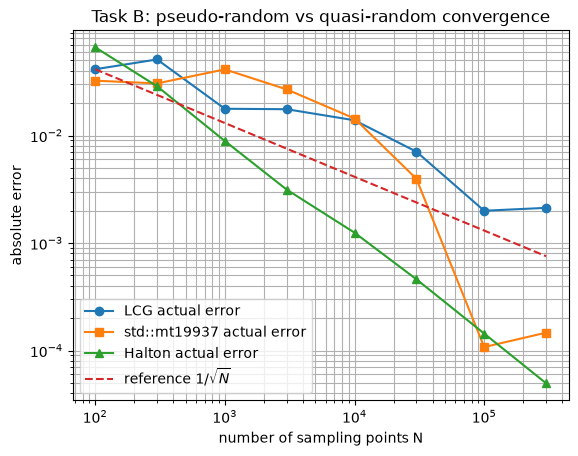

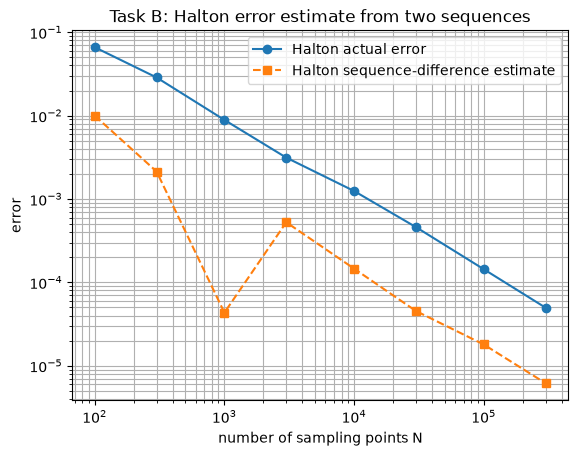

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("mc_B_scaling.data")

N = data[:, 0]
lcg_error = data[:, 1]
std_error = data[:, 2]
halton_error = data[:, 3]
halton_estimated_error = data[:, 4]

reference = lcg_error[0]*np.sqrt(N[0]/N)

eps = 1e-16

plt.figure()
plt.loglog(N, np.maximum(lcg_error, eps), "o-", label="LCG actual error")
plt.loglog(N, np.maximum(std_error, eps), "s-", label="std::mt19937 actual error")
plt.loglog(N, np.maximum(halton_error, eps), "^-", label="Halton actual error")
plt.loglog(N, reference, "--", label=r"reference $1/\sqrt{N}$")
plt.xlabel("number of sampling points N")
plt.ylabel("absolute error")
plt.title("Task B: pseudo-random vs quasi-random convergence")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure()
plt.loglog(N, np.maximum(halton_error, eps), "o-", label="Halton actual error")
plt.loglog(N, np.maximum(halton_estimated_error, eps), "s--", label="Halton sequence-difference estimate")
plt.xlabel("number of sampling points N")
plt.ylabel("error")
plt.title("Task B: Halton error estimate from two sequences")
plt.legend()
plt.grid(True, which="both")
plt.show()

## Task B conclusion

In Task B, quasi-random Monte Carlo integration was implemented using Halton sequences.

The method was compared with two pseudo-random generators: a simple linear congruential generator and the standard C++ `std::mt19937` generator. For the smooth test integral,

$$
\int_0^1 \int_0^1 e^{x+y}\,dx\,dy = (e-1)^2,
$$

the Halton sequence converged faster than the pseudo-random methods. The error decreased more smoothly and became significantly smaller for large values of $N$.

The difficult singular three-dimensional integral was also tested. For this integral the Halton result was not necessarily better than the pseudo-random result. This is acceptable, since the integral is singular and was included mainly as a difficult comparison test.

Overall, the quasi-random Halton method works as intended. It is especially effective for smooth integrands, where the more uniform coverage of the integration region gives better convergence than ordinary random sampling.

# Task C: Stratified sampling

In this task I implement a recursive stratified Monte Carlo integrator.

The idea is to divide the integration region into subregions and allocate more sampling points to the parts of the region where the integrand has the largest variance. This can reduce the error compared with plain Monte Carlo integration.

The algorithm is:

1. Sample a small number of points to estimate the variance in the region.
2. Find the coordinate direction with the largest sub-variance.
3. Split the integration volume along this direction.
4. Distribute the remaining sampling points between the two subregions.
5. Recursively integrate the two subregions.
6. Add the two partial integrals and combine the errors in quadrature.

In [10]:
from pathlib import Path

Path("mc_stratified.hpp").write_text(r'''
#pragma once

#include "mc.hpp"

#include <algorithm>
#include <cmath>
#include <functional>
#include <stdexcept>
#include <vector>

namespace pp {

struct strat_result {
    double value;
    double error;
    int calls;
};

inline double volume_of_box(const vector& a, const vector& b) {
    double V = 1.0;
    for (int i = 0; i < static_cast<int>(a.size()); ++i) {
        V *= b[i] - a[i];
    }
    return V;
}

template<class RNG>
strat_result plainmc_counted(
    const std::function<double(const vector&)>& f,
    const vector& a,
    const vector& b,
    int N,
    RNG& rng
) {
    if (N < 2) {
        N = 2;
    }

    int dim = static_cast<int>(a.size());
    double V = volume_of_box(a, b);

    double sum = 0.0;
    double sum2 = 0.0;

    vector x(dim);

    for (int i = 0; i < N; ++i) {
        for (int k = 0; k < dim; ++k) {
            x[k] = a[k] + rng()*(b[k] - a[k]);
        }

        double fx = f(x);
        sum += fx;
        sum2 += fx*fx;
    }

    double mean = sum/N;
    double var = sum2/N - mean*mean;

    if (var < 0.0) {
        var = 0.0;
    }

    double value = V*mean;
    double error = V*std::sqrt(var/N);

    return strat_result{value, error, N};
}

inline double variance_from_sums(double sum, double sum2, int n) {
    if (n < 2) {
        return 0.0;
    }

    double mean = sum/n;
    double var = sum2/n - mean*mean;

    if (var < 0.0) {
        var = 0.0;
    }

    return var;
}

template<class RNG>
strat_result stratifiedmc(
    const std::function<double(const vector&)>& f,
    const vector& a,
    const vector& b,
    int N,
    RNG& rng,
    int nmin = 64,
    int depth = 0,
    int max_depth = 30
) {
    if (a.size() != b.size()) {
        throw std::runtime_error("stratifiedmc: a and b must have same dimension");
    }

    int dim = static_cast<int>(a.size());

    if (N <= 4*nmin || depth >= max_depth) {
        return plainmc_counted(f, a, b, N, rng);
    }

    vector mid(dim);
    for (int k = 0; k < dim; ++k) {
        mid[k] = 0.5*(a[k] + b[k]);
    }

    std::vector<std::vector<int>> count(dim, std::vector<int>(2, 0));
    std::vector<std::vector<double>> sum(dim, std::vector<double>(2, 0.0));
    std::vector<std::vector<double>> sum2(dim, std::vector<double>(2, 0.0));

    vector x(dim);

    for (int i = 0; i < nmin; ++i) {
        for (int k = 0; k < dim; ++k) {
            x[k] = a[k] + rng()*(b[k] - a[k]);
        }

        double fx = f(x);

        for (int k = 0; k < dim; ++k) {
            int side = x[k] < mid[k] ? 0 : 1;

            count[k][side] += 1;
            sum[k][side] += fx;
            sum2[k][side] += fx*fx;
        }
    }

    int split_dim = 0;
    double best_score = -1.0;

    std::vector<double> var_left(dim);
    std::vector<double> var_right(dim);

    for (int k = 0; k < dim; ++k) {
        var_left[k] = variance_from_sums(sum[k][0], sum2[k][0], count[k][0]);
        var_right[k] = variance_from_sums(sum[k][1], sum2[k][1], count[k][1]);

        double score = var_left[k] + var_right[k];

        if (score > best_score) {
            best_score = score;
            split_dim = k;
        }
    }

    vector a_left = a;
    vector b_left = b;
    vector a_right = a;
    vector b_right = b;

    b_left[split_dim] = mid[split_dim];
    a_right[split_dim] = mid[split_dim];

    double s_left = std::sqrt(var_left[split_dim]);
    double s_right = std::sqrt(var_right[split_dim]);

    int remaining = N - nmin;

    int N_left;
    int N_right;

    if (s_left + s_right > 0.0) {
        N_left = static_cast<int>(
            std::round(remaining*s_left/(s_left + s_right))
        );
    } else {
        N_left = remaining/2;
    }

    N_left = std::max(nmin, std::min(remaining - nmin, N_left));
    N_right = remaining - N_left;

    auto left = stratifiedmc(f, a_left, b_left, N_left, rng, nmin, depth + 1, max_depth);
    auto right = stratifiedmc(f, a_right, b_right, N_right, rng, nmin, depth + 1, max_depth);

    double value = left.value + right.value;
    double error = std::sqrt(left.error*left.error + right.error*right.error);
    int calls = nmin + left.calls + right.calls;

    return strat_result{value, error, calls};
}

} // namespace pp
''')

print("Wrote mc_stratified.hpp")

Wrote mc_stratified.hpp


In [11]:
Path("mc_C.cpp").write_text(r'''
#include "mc.hpp"
#include "mc_stratified.hpp"

#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <vector>

double gaussian_1d_integral(double alpha, double center) {
    const double pi = std::acos(-1.0);

    return std::sqrt(pi)/(2.0*std::sqrt(alpha))
        * (
            std::erf(std::sqrt(alpha)*(1.0 - center))
            + std::erf(std::sqrt(alpha)*center)
        );
}

int main() {
    std::cout << std::setprecision(12);

    std::cout << "Task C: recursive stratified sampling\n";
    std::cout << "-------------------------------------\n\n";

    pp::vector a = {0.0, 0.0};
    pp::vector b = {1.0, 1.0};

    double alpha = 80.0;
    double cx = 0.75;
    double cy = 0.25;

    auto peak_function = [=](const pp::vector& x) {
        double dx = x[0] - cx;
        double dy = x[1] - cy;

        return std::exp(-alpha*(dx*dx + dy*dy));
    };

    double exact =
        gaussian_1d_integral(alpha, cx)
        * gaussian_1d_integral(alpha, cy);

    std::cout << "Test integral:\n";
    std::cout << "f(x,y) = exp(-alpha*((x-cx)^2 + (y-cy)^2))\n";
    std::cout << "alpha = " << alpha << "\n";
    std::cout << "cx    = " << cx << "\n";
    std::cout << "cy    = " << cy << "\n";
    std::cout << "exact integral = " << exact << "\n\n";

    std::vector<int> Ns = {
        1000, 3000, 10000, 30000, 100000, 300000
    };

    std::ofstream out("mc_C_stratified.data");
    out << "# N plain_value plain_error plain_actual strat_value strat_error strat_actual strat_calls\n";

    for (int N : Ns) {
        pp::std_rng rng_plain(12345);
        pp::std_rng rng_strat(12345);

        auto plain = pp::plainmc(peak_function, a, b, N, rng_plain);
        auto strat = pp::stratifiedmc(peak_function, a, b, N, rng_strat, 64);

        double plain_actual = std::abs(plain.value - exact);
        double strat_actual = std::abs(strat.value - exact);

        out << N << " "
            << plain.value << " "
            << plain.error << " "
            << plain_actual << " "
            << strat.value << " "
            << strat.error << " "
            << strat_actual << " "
            << strat.calls << "\n";

        std::cout << "N = " << std::setw(8) << N << "\n";
        std::cout << "  plain       value = " << plain.value
                  << "  actual error = " << plain_actual
                  << "  estimated error = " << plain.error << "\n";

        std::cout << "  stratified  value = " << strat.value
                  << "  actual error = " << strat_actual
                  << "  estimated error = " << strat.error
                  << "  calls = " << strat.calls << "\n\n";
    }

    std::cout << "Wrote mc_C_stratified.data\n";

    return 0;
}
''')

print("Wrote mc_C.cpp")

Wrote mc_C.cpp


In [12]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "mc_C.cpp",
    "-o",
    "mc_C"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./mc_C"], text=True, capture_output=True, timeout=30)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task C: recursive stratified sampling
-------------------------------------

Test integral:
f(x,y) = exp(-alpha*((x-cx)^2 + (y-cy)^2))
alpha = 80
cx    = 0.75
cy    = 0.25
exact integral = 0.0392084590245

N =     1000
  plain       value = 0.0462264113212  actual error = 0.00701795229667  estimated error = 0.00478681879555
  stratified  value = 0.0380057551645  actual error = 0.00120270386005  estimated error = 0.00276193060257  calls = 1000

N =     3000
  plain       value = 0.0439607496199  actual error = 0.00475229059533  estimated error = 0.00265406815508
  stratified  value = 0.038874330978  actual error = 0.000334128046492  estimated error = 0.00121360103879  calls = 3000

N =    10000
  plain       value = 0.0408568106569  actual error = 0.00164835163238  estimated error = 0.00138537325412
  stratified  value = 0.0396565935673  actual error = 0.000448134542765  estimated error = 0.000653823643497  calls = 10000

N =    30000
  plain       val

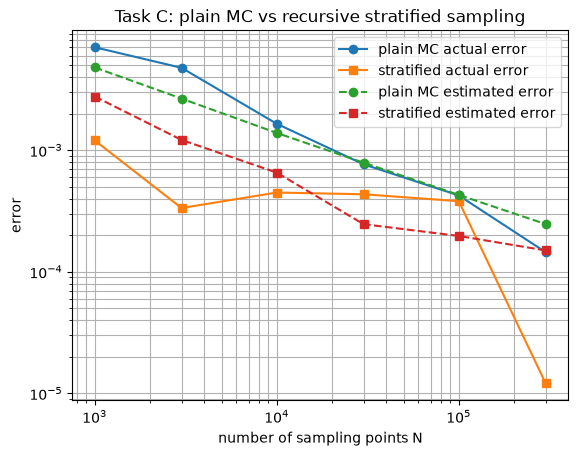

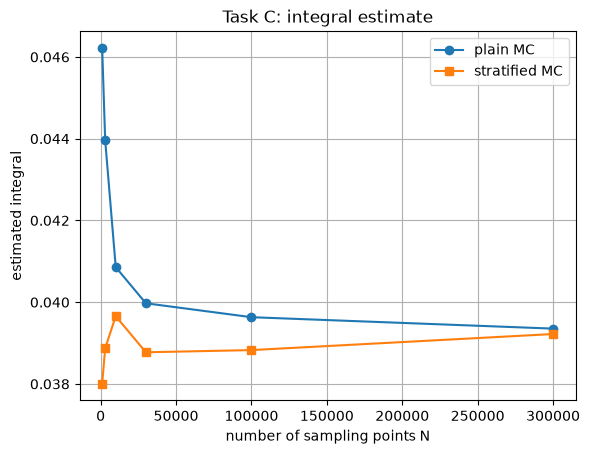

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("mc_C_stratified.data")

N = data[:, 0]
plain_value = data[:, 1]
plain_error = data[:, 2]
plain_actual = data[:, 3]
strat_value = data[:, 4]
strat_error = data[:, 5]
strat_actual = data[:, 6]
strat_calls = data[:, 7]

eps = 1e-16

plt.figure()
plt.loglog(N, np.maximum(plain_actual, eps), "o-", label="plain MC actual error")
plt.loglog(N, np.maximum(strat_actual, eps), "s-", label="stratified actual error")
plt.loglog(N, np.maximum(plain_error, eps), "o--", label="plain MC estimated error")
plt.loglog(N, np.maximum(strat_error, eps), "s--", label="stratified estimated error")
plt.xlabel("number of sampling points N")
plt.ylabel("error")
plt.title("Task C: plain MC vs recursive stratified sampling")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure()
plt.plot(N, plain_value, "o-", label="plain MC")
plt.plot(N, strat_value, "s-", label="stratified MC")
plt.xlabel("number of sampling points N")
plt.ylabel("estimated integral")
plt.title("Task C: integral estimate")
plt.legend()
plt.grid(True)
plt.show()

## Task C conclusion

In Task C, recursive stratified sampling was implemented and compared with plain Monte Carlo integration.

The test integral was chosen as a localized two-dimensional Gaussian peak,

$$
f(x,y)=\exp(-\alpha((x-c_x)^2+(y-c_y)^2)),
$$

where the exact integral can be calculated from error functions. This makes it possible to compare the numerical estimates with a known result.

The results show that recursive stratified sampling generally gives a smaller actual error than plain Monte Carlo for the same number of sampling points. This is especially clear for small and intermediate values of $N$, where the stratified method finds the important region of the integration domain more efficiently.

The estimated errors also decrease as $N$ is increased, and the integral estimates converge towards the exact value. The stratified method is therefore useful when the integrand is not equally important everywhere in the integration region.

Thus, the recursive stratified Monte Carlo integrator works as intended and improves the efficiency compared with plain Monte Carlo for this non-uniform test function.